Files originally from https://github.com/LucasSilvaFerreira/Perturb_Loader


In [1]:
import mudata as md
import anndata as ad
import numpy as np
import pandas as pd
import perturbvi
import seaborn as sns
import scanpy as sc
import os
import pyro

smoke_test = False
data_dir = "../../../../Data/gasperini_pilot"


/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Global seed set to 0


In [2]:
# load sceptre list of genes/guides

In [3]:
sceptre_df = pd.read_csv(f"{data_dir}/sceptre_results-2023_01_13.csv")
sceptre_df = sceptre_df.rename(columns={'gRNA_id':'guide', 'gene_id':'gene'})
selected_genes = sceptre_df['gene'].unique()
selected_guides = sceptre_df['guide'].unique()
print (len(selected_genes), len(selected_guides))

5859 1243


In [4]:
def construct_mudata(data_dir="."):
    rna_adata = ad.read_h5ad(f"{data_dir}/ann_exp.h5ad")
    rna_adata.obs["library_size"] = rna_adata.X.sum(axis=1)
    rna_adata.varm["element_tested"] = ad.read_h5ad(f"{data_dir}/ann_Element_x_tested_genes.h5ad").to_df().T
    # sc.pp.filter_genes(rna_adata, min_cells=len(rna_adata)*0.1) # need genes where at least 10% of cells with nonzero counts
    grna_adata = ad.read_h5ad(f"{data_dir}/ann_guide.h5ad")
    grna_adata.varm["element_targeted"] = ad.read_h5ad(f"{data_dir}/ann_Element_guide.h5ad").to_df().T
    assert (rna_adata.varm["element_tested"].columns == grna_adata.varm["element_targeted"].columns).all()
    mdata = md.MuData({"rna": rna_adata, "grna": grna_adata})
    mdata.write_h5mu(f"{data_dir}/gasperini_pilot_highMOI.h5mu")
    return mdata


force = True
mudata_file = "gasperini_pilot_highMOI.h5mu"
if mudata_file not in os.listdir(data_dir) or force:
    mdata = construct_mudata(data_dir)
else:
    mdata = md.read_h5mu(os.path.join(data_dir, mudata_file))
mdata

MuData object with n_obs × n_vars = 47964 × 19482
  2 modalities
    rna:	47964 x 16367
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size'
      varm:	'element_tested'
    grna:	47964 x 3115
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
      varm:	'element_targeted'

In [5]:
# mdata['grna'].varm['gene_targeted']
# mdata['rna'].varm['gene_tested']
mdata["grna"].varm["element_targeted"]


Element,ACTB_TSS,ACTG1_TSS,ACYP1_TSS,ADIPOR1_TSS,ALDH1A2_TSS,APEX1_TSS,APLP2_TSS,ARF6_TSS,ARID1A_TSS,ARL4A_TSS,...,scrambled_24,scrambled_25,scrambled_2,scrambled_3,scrambled_4,scrambled_5,scrambled_6,scrambled_7,scrambled_8,scrambled_9
ACTB_TSS|1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTB_TSS|2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTG1_TSS|1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTG1_TSS|2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACYP1_TSS|1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
scrambled_7|2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
scrambled_8|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
scrambled_8|2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
scrambled_9|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [6]:
guides = mdata["grna"].var_names
# selected_guides = list(guides[guides.str.contains(r"TSS|random|scrambled", regex=True)])
if smoke_test:
    selected_guides = list(guides)
    selected_guides = selected_guides[:20] + selected_guides[-10:]
    print("guides", selected_guides)

elements = list({guide.split("|")[0] for guide in selected_guides})
selected_elements = [e for e in elements if e in mdata["grna"].varm["element_targeted"].columns]
element_subset = mdata["grna"].varm["element_targeted"][selected_elements].copy()

grna_subset = mdata["grna"]
grna_subset.varm["element_targeted"] = element_subset

grna_subset = mdata["grna"][:, selected_guides]
# genes = list(sorted({e.split("_")[0] for e in selected_elements if "_TSS" in e}))
# subset_genes = [g for g in genes if g in mdata["rna"].var_names]
# subset_genes = [subset_genes[1]] # DANGER SINGLE GENE ONLY
# print(selected_genes)

if smoke_test:
    print("elements", selected_elements)
    print("genes", selected_genes)
assert grna_subset.varm["element_targeted"].shape == (len(selected_guides), len(selected_elements))


In [7]:
grna_subset.varm["element_targeted"].shape


(1243, 625)

In [8]:
rna_subset = mdata["rna"]
rna_subset.varm["element_tested"] = rna_subset.varm["element_tested"][selected_elements].copy()
rna_subset = rna_subset[:, selected_genes]
mdata_subset = md.MuData({"rna": rna_subset.copy(), "grna": grna_subset.copy()})
assert (mdata_subset['rna'].varm['element_tested'].columns == mdata_subset['grna'].varm['element_targeted'].columns).all()
mdata_subset


MuData object with n_obs × n_vars = 47964 × 7102
  2 modalities
    rna:	47964 x 5859
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size'
      varm:	'element_tested'
    grna:	47964 x 1243
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
      varm:	'element_targeted'

In [9]:
perturbvi.PERTURBVI.setup_mudata(
    mdata_subset,
    batch_key="bath_number",
    size_factor_key="library_size",
    var_by_element_key="element_tested",
    perturb_by_element_key="element_targeted",
    modalities={
        "rna_layer": "rna",
        "perturbation_layer": "grna",
    },
)

model = perturbvi.PERTURBVI(mdata_subset)
model.view_anndata_setup()


INFO     Using column names from columns of adata.varm['element_tested']                                           
INFO     Using column names from columns of adata.varm['element_targeted']                                         


Anndata setup with scvi-tools version 0.20.1.

Setup via `PERTURBVI.setup_anndata` with arguments:

{
│   'rna_layer': None,
│   'batch_key': 'bath_number',
│   'var_by_element_key': 'element_tested',
│   'perturb_by_element_key': 'element_targeted',
│   'perturbation_layer': None,
│   'modalities': {'rna_layer': 'rna', 'perturbation_layer': 'grna'},
│   'size_factor_key': 'library_size'
}

      Summary Statistics       
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃  Summary Stat Key   ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│       n_batch       │   6   │
│       n_cells       │ 47964 │
│   n_perturbations   │ 1243  │
│ n_targeted_elements │  625  │
│  n_tested_elements  │  625  │
│       n_vars        │ 5859  │
└─────────────────────┴───────┘

                          Data Registry                           
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃   Registry Key    ┃            scvi-tools Location             ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         X         │             adata.mod['rna'].X             │
│       batch       │    adata.mod['rna'].obs['_scvi_batch']     │
│       ind_x       │       adata.mod['rna'].obs['_ind_x']       │
│ observed_lib_size │    adata.mod['rna'].obs['library_size']    │
│   perturbations   │            adata.mod['grna'].X             │
│ targeted_elements │ adata.mod['grna'].varm['element_targeted'] │
│  tested_elements  │  adata.mod['rna'].varm['element_tested']   │
└───────────────────┴────────────────────────────────────────────┘

                     batch State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['bath_number'] │     1      │          0          │
│                          │     2      │          1          │
│                          │     3      │          2          │
│                          │     4      │          3          │
│                          │     5      │          4          │
│                          │     6      │          5          │
└──────────────────────────┴────────────┴─────────────────────┘

In [10]:
mdata_subset['rna'].varm['element_tested']
mdata_subset['grna'].varm['element_targeted']


Element,TRMT10C_TSS,chr10:72420587-72420610,chr11:75269992-75270015,chr12:51426824-51426847,chr14:69291424-69291447,DNAJB6_TSS,TBCA_TSS,LSM3_TSS,chr13:27995629-27995652,DAZAP2_TSS,...,PTP4A2_TSS,chr10:112376245-112376268,TIMM10_TSS,chr11:102212503-102212526,chr12:53374575-53374598,COMMD3_TSS,ZNF273_TSS,MRPL33_TSS,chr10:72335389-72335412,SRRM1_TSS
ACTB_TSS|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTB_TSS|2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTG1_TSS|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTG1_TSS|2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACYP1_TSS|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
scrambled_7|2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
scrambled_8|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
scrambled_8|2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
scrambled_9|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
# burn-in
model.train(10, lr=0.1, batch_size=4096)


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:201: UserWarning: MPS available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='mps', devices=1)`.
  rank_zero_warn(
/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/pytorch_lightning/trainer/configuration_validator.py:106: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")


Epoch 5/10:  40%|████      | 4/10 [02:57<04:25, 44.26s/it, v_num=1, elbo_train=4.38e+8]

In [ ]:
# fine tune
max_epochs = 50
model.train(max_epochs=max_epochs, lr=0.01, batch_size=None)


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:201: UserWarning: MPS available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='mps', devices=1)`.
  rank_zero_warn(
/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/pytorch_lightning/trainer/configuration_validator.py:106: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")
/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/pytorch_lightning/trainer/trainer.py:1609: PossibleUserWarning: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower 

Epoch 50/50: 100%|██████████| 50/50 [01:09<00:00,  1.41s/it, v_num=1, elbo_train=4.3e+7] 

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 50/50: 100%|██████████| 50/50 [01:09<00:00,  1.39s/it, v_num=1, elbo_train=4.3e+7]


In [ ]:
%load_ext autoreload
%autoreload 2
from matplotlib.scale import scale_factory
from pyparsing import col
from scipy.stats import norm
from torch import sign

lfc_threshold = 0.05 # ~ at least 5% knockdown
# lfc_threshold = 0 # nonzero knockdown
# gene_index=45

scale_factor = 0.1
perturb_mean_lfc_mu = pyro.get_param_store()['perturb_mean_lfc.mu'].detach().cpu().numpy()
perturb_disp_lfc_mu = pyro.get_param_store()['perturb_disp_lfc.mu'].detach().cpu().numpy()
lfc_cov_tril = pyro.get_param_store()['perturb_lfc.scale_tril'] * scale_factor
lfc_cov = lfc_cov_tril @ lfc_cov_tril.transpose(dim0=-1, dim1=-2)
perturb_mean_lfc_sigma = lfc_cov[...,0,0].sqrt().detach().cpu().numpy()
perturb_disp_lfc_sigma = lfc_cov[...,0,0].sqrt().detach().cpu().numpy()
assert perturb_mean_lfc_mu.shape == perturb_mean_lfc_sigma.shape
perturb_z_scores = perturb_mean_lfc_mu/perturb_mean_lfc_sigma
perturb_p_vals = norm.cdf(lfc_threshold, loc=-perturb_mean_lfc_mu, scale=perturb_mean_lfc_sigma)

results_all_df = (
    pd.DataFrame(data=perturb_z_scores, columns=subset_genes, index=selected_guides)
    .melt(var_name="gene", ignore_index=False)
    .reset_index(names="guide")
    .sort_values("value")
    .assign(is_target=lambda x: x['guide'].str.split('_', expand=True)[0]==x['gene'])
)
# significant_results['guide'].str.split("_", expand=True)[0]
# significant_results.head(1000).to_excel("~/Downloads/significant_results.xlsx")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<Axes: xlabel='value', ylabel='Density'>

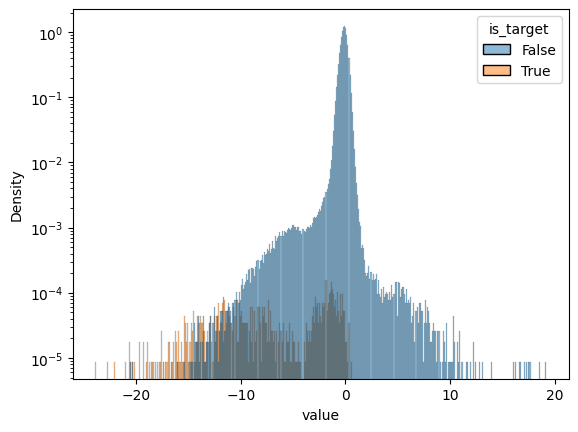

In [ ]:
from cmath import log


sns.histplot(
    results_all_df,
    hue="is_target",
    x="value",
    # common_norm=False,
    log_scale=[False, True],
    stat="density",
    binwidth=0.1,
)
# significant_results.groupby("guide").count()['gene'].sort_values().tail(20)
# significant_results.to_excel("significant_results.xlsx")
# # perturb_z_scores[:,gene_index].detach().cpu().numpy()
# z_df = pd.DataFrame({'z_score': perturb_z_scores[:,gene_index],
#                     'mean_mu': perturb_mean_lfc_mu[:,gene_index],
#                     'disp_mu': perturb_disp_lfc_mu[:,gene_index],
#                     'mu_p_val': perturb_p_vals[:,gene_index],
#                     'grna': mdata_subset['grna'].var_names,})
# # z_df.hist('mu_p_val', bins=100)
# names[gene_index])
# print(z_df.sort_values('mu_p_val', ascending=True).reset_index(drop=True).head(20))


<Axes: ylabel='Count'>

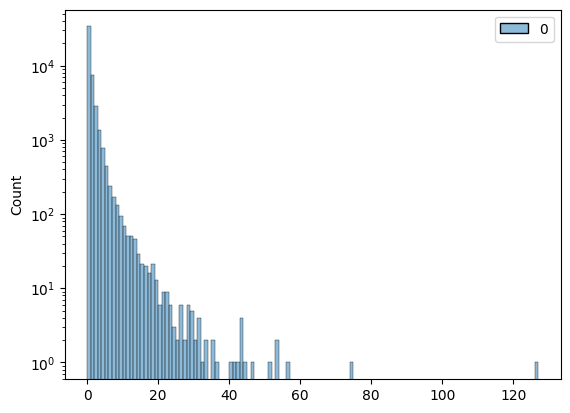

In [ ]:
import scanpy as sc
sns.histplot(mdata['rna'][:,'DLK1'].X.todense(), binwidth=1, log_scale=[False, True])

## Compare to SCEPTRE results

5859

In [ ]:
merge_df = pd.merge(sceptre_df, results_all_df, how="inner")


In [ ]:
sns.scatterplot(merge_df, x="z_value", y="value", hue="is_target")


,guide,gene,value,is_target
897719,SERPINB1_TSS|2,SERPINB1,-23.897980,True
801089,RHAG_TSS|1,RHAG,-22.717545,True
879015,SAMSN1_TSS|2,SAMSN1,-22.010639,True
1000580,TMEM14C_TSS|2,TMEM14C,-21.089758,True
199501,CTCFL_TSS|2,CTCFL,-20.666359,True
...,...,...,...,...
231405,chr11:33966182-33966205|1,DLK1,17.392122,False
399293,RPL3_TSS|2,ID2,17.509773,False
819818,RPL3_TSS|2,RNF2,17.650354,False
477173,RPS3_TSS|1,MAN1A1,18.589764,False
